In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.io
import torch
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from emle.models import EMLE
from emle.train._utils import pad_to_max
import pickle as pkl

warnings.filterwarnings("ignore")

color_by_z = {1: "grey", 6: "cyan", 7: "blue", 8: "red", 16: "yellow"}
ANGSTROM_TO_BOHR = 1.8897259886
HARTREE_TO_KJ_MOL = 2625.5002

/home/joaomorado/micromamba/envs/fes-ml-aev/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

### Load Data

In [3]:
data = pkl.load(open("training_data_iter2.pkl", "rb"))

# Get padded tensors
z = pad_to_max(data["z"]).to(device=device, dtype=torch.long)
xyz_qm = pad_to_max(data["xyz_qm"]).to(device=device, dtype=dtype)
xyz_mm = pad_to_max(data["xyz_mm"]).to(device=device, dtype=dtype)
charges_mm = pad_to_max(data["charges_mm"]).to(device=device, dtype=dtype)

### Assign TIP3P LJ Parameters

In [4]:
# TIP3P LJ Parameters
# O_sigma = 3.1507 Å, O_epsilon = 0.1521 kcal/mol
# H_sigma = 1.0 Å, H_epsilon = 0.0 kcal/mol
O_sigma = 3.1507 * ANGSTROM_TO_BOHR
O_epsilon = 0.1521 / HARTREE_TO_KJ_MOL
H_sigma = 1.0 * ANGSTROM_TO_BOHR
H_epsilon = 0.0 / HARTREE_TO_KJ_MOL

sigma_mm = charges_mm.clone()
sigma_mm[charges_mm == -0.834] = O_sigma
sigma_mm[charges_mm == 0.417] = H_sigma

epsilon_mm = charges_mm.clone()
epsilon_mm[charges_mm == -0.834] = O_epsilon
epsilon_mm[charges_mm == 0.417] = H_epsilon

# Now pad adding 0s for the QM atoms
num_qm_atoms = z.shape[1]
sigma_mm = torch.cat(
    [torch.zeros((sigma_mm.shape[0], num_qm_atoms), device=device, dtype=dtype), sigma_mm],
    dim=1,
)
epsilon_mm = torch.cat(
    [torch.zeros((epsilon_mm.shape[0], num_qm_atoms), device=device, dtype=dtype), epsilon_mm],
    dim=1,
)

# Get idx_mm
atom_indices = torch.arange(charges_mm.shape[1]).unsqueeze(0).expand(*charges_mm.shape).to(device=device, dtype=torch.long)
idx_mm = torch.where(charges_mm != 0.0, atom_indices + num_qm_atoms, 0)

# Recreate nagl_params dictionary
nagl_params = {
    "lj_sigma_mm": sigma_mm,
    "lj_eps_mm": epsilon_mm,
}

### Create EMLE model

In [5]:
model = "ligand_patched_reference_iter2_c6_sigma_scales_ones.mat"
emle = EMLE(model=model, device=device, dtype=dtype, alpha_mode="reference", dispersion_mode="lj", nagl_params=nagl_params)
emle_base = emle._emle_base

### Fine-tune the Fedorov relation via Zwanzig reweighting

In [6]:
def dG(energies, beta):
    """Compute solvation free energy using Zwanzig equation."""
    return -(1/beta) * torch.logsumexp(-beta * energies, dim=1) + (1/beta) * torch.log(torch.tensor(energies.shape[1], dtype=torch.float32))

In [7]:
# Define constants
T = 298.15  
kbT = 3.166811563e-6 * T
beta = 1.0 / kbT
NMOL = 20 

In [ ]:
# Calculate dG-LJ
with torch.no_grad():
    e_static, e_ind, _, _, e_lj = emle.forward(z, charges_mm, xyz_qm, xyz_mm, idx_mm=idx_mm)

dG_lj_init = dG(e_lj.view(NMOL, -1), beta)

mols = ['1_4-dioxane', 
        '1-propanethiol', 
        '2-pentanone', 
        'aceticacid', 
        'acetonitrile',
        'aniline', 
        'benzamide', 
        'benzene', 
        'ethylphenylether', 
        'methanol', 
        'methylbenzoate',
        'methylpentanoate', 
        'm-hydroxybenzaldehyde', 
        'naphthalene', 
        'n-octane', 
        'n-pentane',
        'o-cresol', 
        'pyridine', 
        'thioanisole', 
        'water']

sign_err = [
    0.75,    # 1_4-dioxane
    1.46,    # 1-propanethiol
    0.03,    # 2-pentanone
    0.99,    # aceticacid
   -1.55,    # acetonitrile
    0.00,    # aniline
    0.42,    # benzamide
   -0.88,    # benzene
   -0.30,    # ethylphenylether
    1.10,    # methanol
   -1.49,    # methylbenzoate
   -0.53,    # methylpentanoate
    0.90,    # m-hydroxybenzaldehyde
   -0.91,    # naphthalene
    0.35,    # n-octane
    0.48,    # n-pentane
    1.59,    # o-cresol
   -0.09,    # pyridine
    0.60,    # thioanisole
    0.00     # water
]

# Signed errors
sign_err = torch.tensor(sign_err) * 4.184 / HARTREE_TO_KJ_MOL  
# DeltaG_calc - (DeltaG_calc - DeltaG_exp) = DeltaG_exp
dG_lj_ref = dG_lj_init - sign_err.to(device=device, dtype=dtype)

In [9]:
# Optimize
sigma_scale = emle._emle_base.ref_values_sigma_scale
optimizer = torch.optim.Adam([sigma_scale], lr=1e-3)
n_epochs = 500
for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Get the LJ deltaG with the updated parameters
    *_, e_lj = emle.forward(z, charges_mm, xyz_qm, xyz_mm, idx_mm=idx_mm)
    e_lj = e_lj.view(NMOL, -1)
    dG_lj = dG(e_lj, beta)

    # Update sigma scale for gpr
    emle_base._ref_mean_sigma_scale, emle_base._c_sigma_scale = emle_base._get_c(
            emle_base._n_ref,
            emle_base.ref_values_sigma_scale,
            emle_base._Kinv,
        )
    
    # Regularize sigma scale to be close to 1.0
    mask = (
        torch.arange(
            emle_base.ref_values_sigma_scale.shape[1],
            device=emle_base._n_ref.device,
        )
        < emle_base._n_ref[:, None]
    )
    reg_loss = (
        1e-2
        * torch.sum((emle_base.ref_values_sigma_scale - 1) ** 2 * mask)
        / torch.sum(emle_base._n_ref)
    )

    # Compute loss
    loss = torch.mean((dG_lj - dG_lj_ref) ** 2) / torch.std(dG_lj_ref)
    loss += reg_loss
    loss.backward(retain_graph=True)
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.6f}")

# Save EMLE model with updated parameters
model_mat = scipy.io.loadmat(model)
model_mat["sigma_scale_ref"] = emle_base.ref_values_sigma_scale.detach().cpu().numpy()
scipy.io.savemat("ligand_patched_reference_iter2_c6_updated_sigma_scale.mat", model_mat)

Epoch 10/500, Loss: 0.000341
Epoch 20/500, Loss: 0.000280
Epoch 30/500, Loss: 0.000234
Epoch 40/500, Loss: 0.000199
Epoch 50/500, Loss: 0.000172
Epoch 60/500, Loss: 0.000151
Epoch 70/500, Loss: 0.000135
Epoch 80/500, Loss: 0.000122
Epoch 90/500, Loss: 0.000112
Epoch 100/500, Loss: 0.000104
Epoch 110/500, Loss: 0.000098
Epoch 120/500, Loss: 0.000092
Epoch 130/500, Loss: 0.000088
Epoch 140/500, Loss: 0.000085
Epoch 150/500, Loss: 0.000082
Epoch 160/500, Loss: 0.000079
Epoch 170/500, Loss: 0.000077
Epoch 180/500, Loss: 0.000076
Epoch 190/500, Loss: 0.000074
Epoch 200/500, Loss: 0.000073
Epoch 210/500, Loss: 0.000072
Epoch 220/500, Loss: 0.000071
Epoch 230/500, Loss: 0.000070
Epoch 240/500, Loss: 0.000069
Epoch 250/500, Loss: 0.000069
Epoch 260/500, Loss: 0.000068
Epoch 270/500, Loss: 0.000068
Epoch 280/500, Loss: 0.000067
Epoch 290/500, Loss: 0.000067
Epoch 300/500, Loss: 0.000066
Epoch 310/500, Loss: 0.000066
Epoch 320/500, Loss: 0.000065
Epoch 330/500, Loss: 0.000065
Epoch 340/500, Loss

# Plots

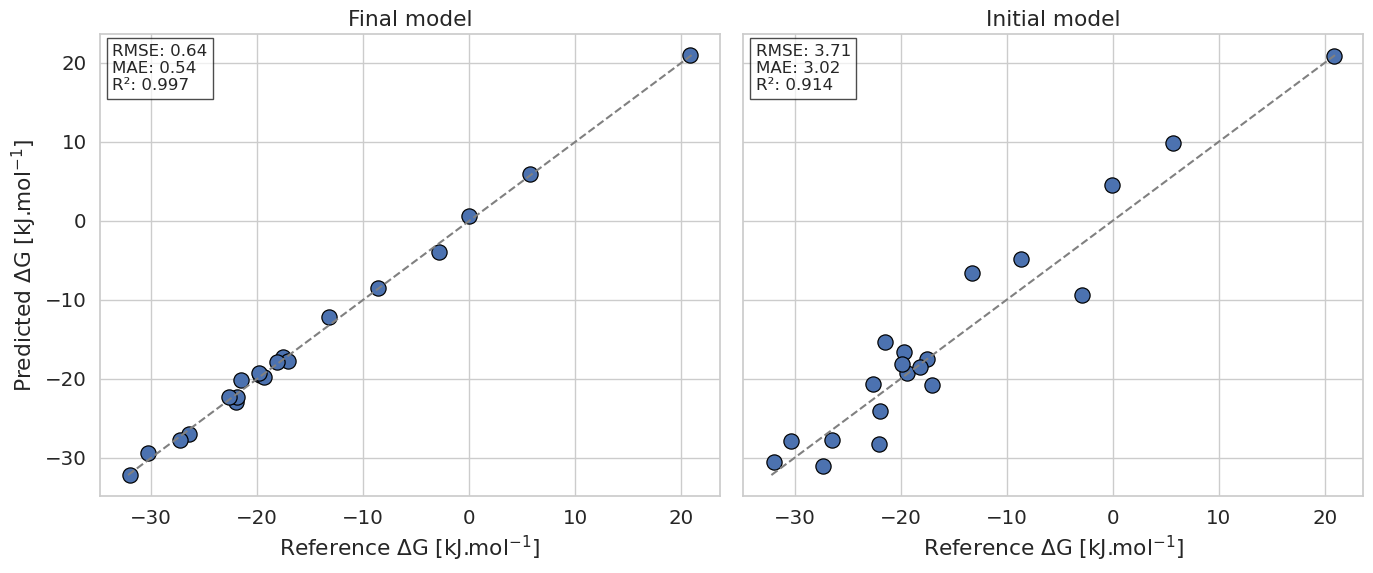

In [10]:
sns.set(style="whitegrid", font_scale=1.3)

dG_lj_calc = dG_lj.detach().cpu().numpy() * HARTREE_TO_KJ_MOL
dG_lj_init = dG_lj_init.detach().cpu().numpy() * HARTREE_TO_KJ_MOL
dG_ref = dG_lj_ref.detach().cpu().numpy() * HARTREE_TO_KJ_MOL

stats_calc = (
    np.sqrt(mean_squared_error(dG_ref, dG_lj_calc)),
    mean_absolute_error(dG_ref, dG_lj_calc),
    r2_score(dG_ref, dG_lj_calc)
)
stats_init = (
    np.sqrt(mean_squared_error(dG_ref, dG_lj_init)),
    mean_absolute_error(dG_ref, dG_lj_init),
    r2_score(dG_ref, dG_lj_init)
)

min_v = min(dG_ref.min(), dG_lj_calc.min(), dG_lj_init.min())
max_v = max(dG_ref.max(), dG_lj_calc.max(), dG_lj_init.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Final model
ax = axes[0]
sns.scatterplot(x=dG_ref, y=dG_lj_calc, s=120, edgecolor="black", ax=ax)
ax.plot([min_v, max_v], [min_v, max_v], "--", color="gray", linewidth=1.5)
ax.set_title("Final model")
ax.set_xlabel("Reference ΔG [kJ.mol$^{-1}$]")
ax.set_ylabel("Predicted ΔG [kJ.mol$^{-1}$]")

rmse, mae, r2 = stats_calc
ax.text(
    0.02, 0.98,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
)

# Initial model
ax = axes[1]
sns.scatterplot(x=dG_ref, y=dG_lj_init, s=120, edgecolor="black", ax=ax)
ax.plot([min_v, max_v], [min_v, max_v], "--", color="gray", linewidth=1.5)
ax.set_title("Initial model")
ax.set_xlabel("Reference ΔG [kJ.mol$^{-1}$]")
ax.set_ylabel("") 

rmse, mae, r2 = stats_init
ax.text(
    0.02, 0.98,
    f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
)

plt.tight_layout()
plt.show()

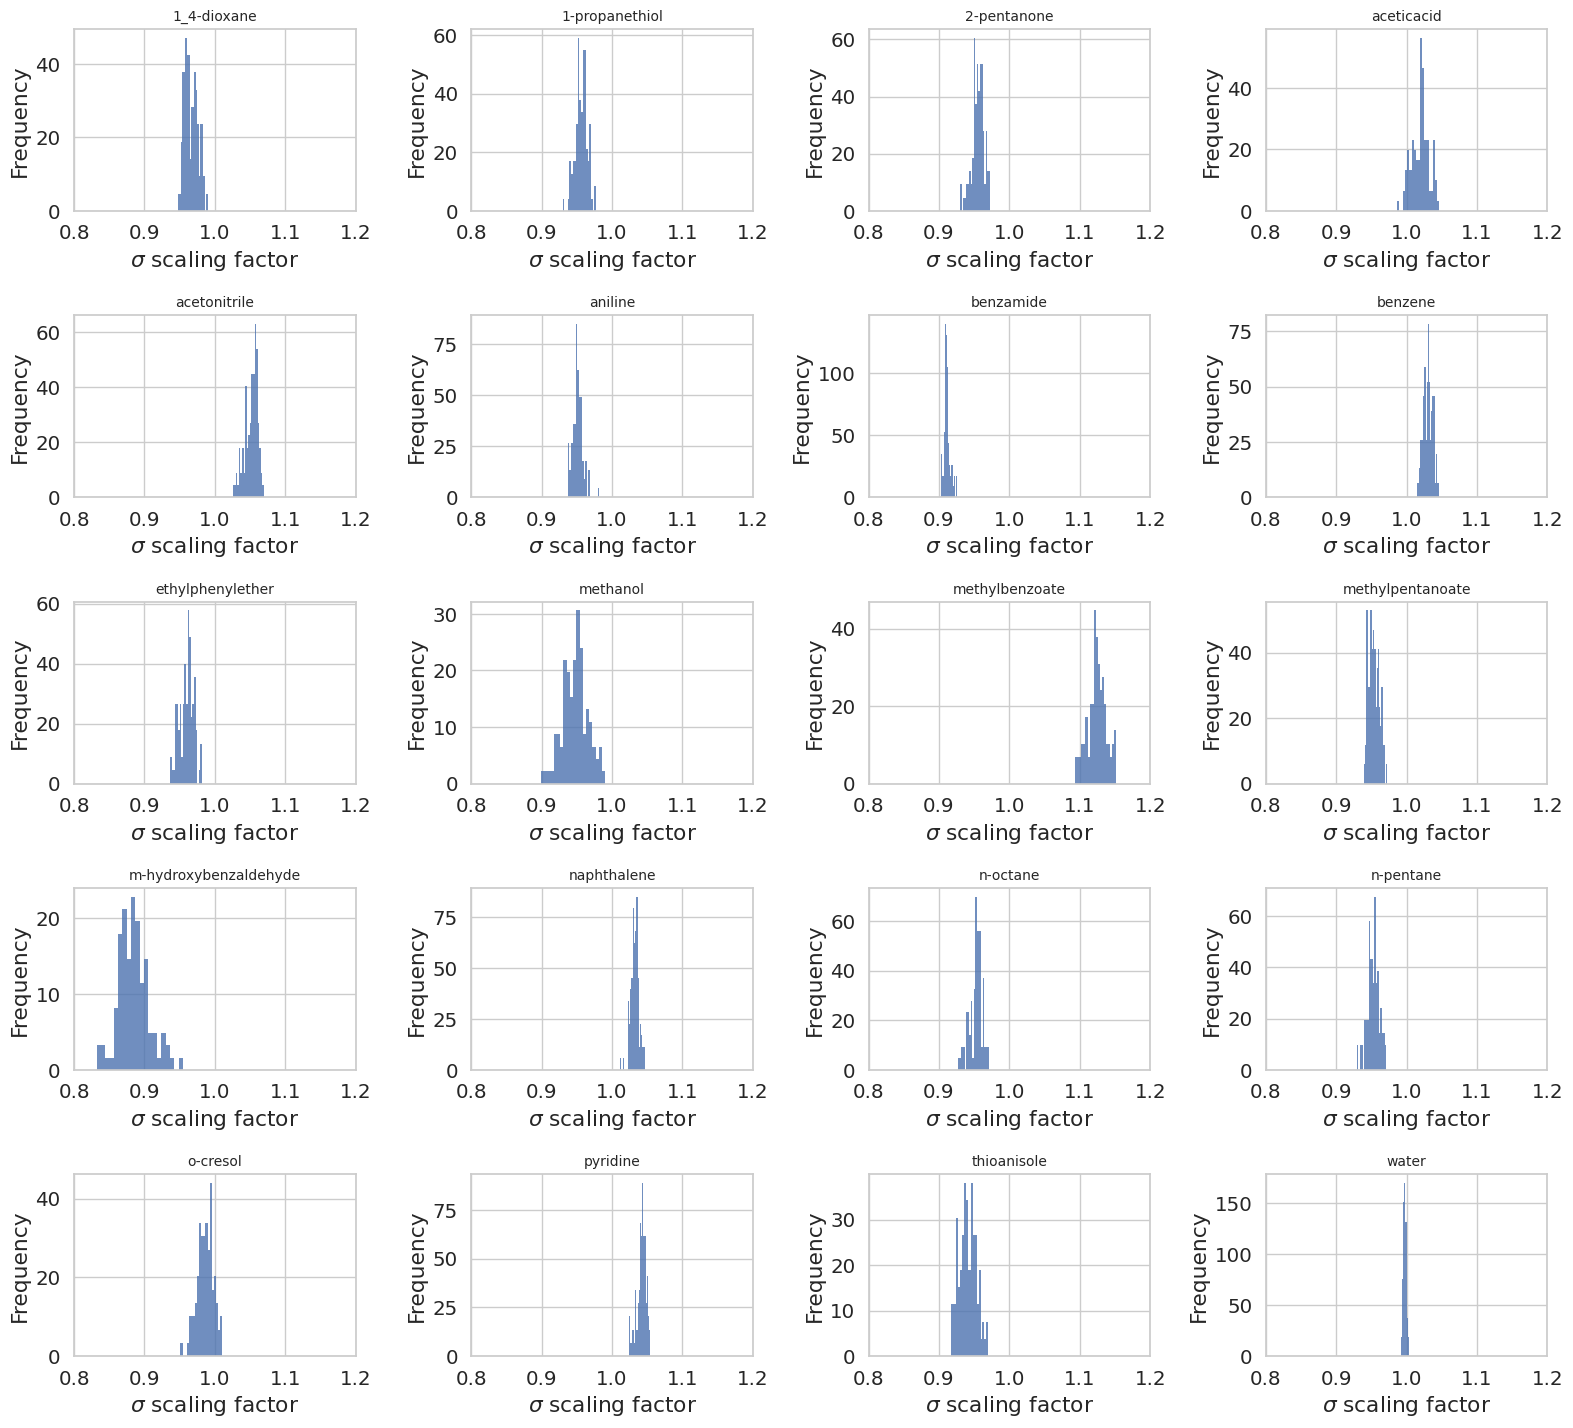

In [11]:


x = np.loadtxt("sigma_scale.txt")

# One block per molecule
chunk_size = int(x.shape[0] / len(mols))

num_mols = len(mols)
n_cols = 4 
n_rows = math.ceil(num_mols / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, mol in enumerate(mols):
    ax = axes[i]
    data_block = x[i*chunk_size : (i+1)*chunk_size, 0]
    ax.hist(data_block, bins=20, alpha=0.8, density=True, edgecolor=None, linewidth=0)
    ax.set_title(mol, fontsize=10)
    ax.set_xlabel(r"$\sigma$ scaling factor")
    ax.set_ylabel("Frequency")
    ax.set_xlim(0.8, 1.2)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].axis("off")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

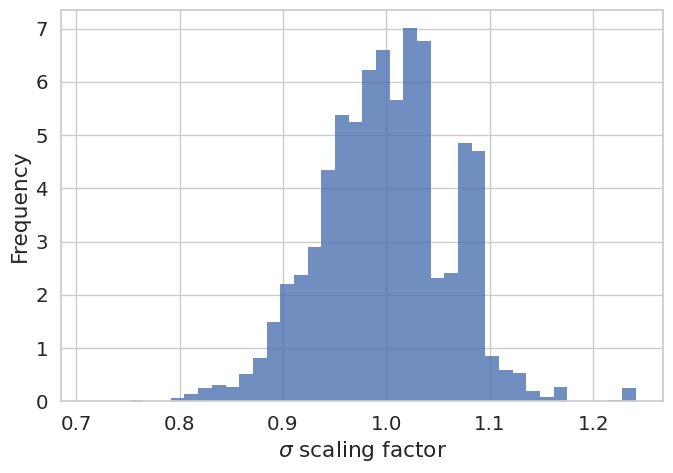

In [12]:
all_sigma = x.flatten()
all_sigma = all_sigma[all_sigma > 0.0]

plt.figure(figsize=(7, 5))
plt.hist(all_sigma, bins=40, alpha=0.8, density=True, edgecolor=None, linewidth=0)
plt.xlabel(r"$\sigma$ scaling factor")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()